In [4]:
!pip install medmnist

  Using cached medmnist-3.0.2-py3-none-any.whl.metadata (14 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
Using cached medmnist-3.0.2-py3-none-any.whl (25 kB)
Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl (664.8 MB)
Using cached nvidia_cusolver_cu12-11.6.1.9-py3-none-manylinux2014_x86_64.whl (127.9 MB)
  Attempting uninstall: nvidia-cusolver-cu12
    Found existing installation: nvidia-cusolver-cu12 11.6.3.83
    Uninstalling nvidia-cusolver-cu12-11.6.3.83:
      Successfully uninstalled nvidia-cusolver-cu12-11.6.3.83


In [5]:
! pip install -q neptune

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.9/487.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.7 MB/s eta 0:00:00


In [6]:
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torchvision import models
import neptune

import medmnist
from medmnist import INFO, Evaluator

In [7]:
NEPTUNE_PROJECT_NAME = "sigk/neural-rendering"
NEPTUNE_API_KEY = input("Enter Neptune API key: ")

Enter Neptune API key: eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJlZmIwZTU3OS0xZmJjLTRiZjEtODZmNS0yOGI2NjI1ZjE4NDgifQ==


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
data_flag = 'bloodmnist'
# data_flag = 'dermamnist'
# data_flag = 'pathmnist'
download = True

NUM_EPOCHS = 10
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [10]:
# # preprocessing
# data_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[.5], std=[.5])
# ])

# # load the data
# train_dataset = DataClass(split='train', transform=data_transform, download=download)
# test_dataset = DataClass(split='test', transform=data_transform, download=download)

# pil_dataset = DataClass(split='train', download=download)

# # encapsulate data into dataloader form
# train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
# test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)


In [11]:
# print(train_dataset)
# print("===================")
# print(test_dataset)

In [12]:
# visualization

# train_dataset.montage(length=1)

In [13]:
# montage

# train_dataset.montage(length=20)

In [14]:
# class MedModel(nn.Module):
#     def __init__(self, in_channels, num_classes):
#         super(MedModel, self).__init__()

#         # 1. Pobierz model z wagami ImageNet
#         self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#         for param in self.model.parameters():
#           param.requires_grad = False

#         # 2. Zmniejsz kernel i stride w conv1 (dla małych obrazków)
#         # self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

#         # 3. Wywal maxpool, bo dla małych obrazów zjada za dużo informacji
#         # self.model.maxpool = nn.Identity()

#         # 4. Zamień ostatnią warstwę FC na własną
#         in_features = self.model.fc.in_features
#         self.model.fc = nn.Linear(in_features, num_classes)

#     def forward(self, x):
#         return self.model(x)

# model = MedModel(in_channels=n_channels, num_classes=n_classes)

# # define loss function and optimizer
# if task == "multi-label, binary-class":
#     criterion = nn.BCEWithLogitsLoss()
# else:
#     criterion = nn.CrossEntropyLoss()

# params_to_update = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.Adam(params_to_update, lr=lr)

In [15]:
# # train
# model = model.to(device)


# for epoch in range(NUM_EPOCHS):
#     train_correct = 0
#     train_total = 0
#     test_correct = 0
#     test_total = 0

#     model.train()
#     for inputs, targets in tqdm(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device)
#         # forward + backward + optimize
#         optimizer.zero_grad()
#         outputs = model(inputs)

#         if task == 'multi-label, binary-class':
#             targets = targets.to(torch.float32)
#             loss = criterion(outputs, targets)
#         else:
#             targets = targets.squeeze().long()
#             loss = criterion(outputs, targets)

#         loss.backward()
#         optimizer.step()

In [16]:
# # evaluation

# def test(split):
#     model.eval()
#     y_true = torch.tensor([])
#     y_score = torch.tensor([])
#     y_true = y_true.to(device)
#     y_score = y_score.to(device)

#     data_loader = train_loader_at_eval if split == 'train' else test_loader

#     with torch.no_grad():
#         for inputs, targets in data_loader:
#             inputs = inputs.to(device)
#             targets = targets.to(device)
#             outputs = model(inputs)

#             if task == 'multi-label, binary-class':
#                 targets = targets.to(torch.float32)
#                 outputs = outputs.softmax(dim=-1)
#             else:
#                 targets = targets.squeeze().long()
#                 outputs = outputs.softmax(dim=-1)
#                 targets = targets.float().resize_(len(targets), 1)

#             y_true = torch.cat((y_true, targets), 0)
#             y_score = torch.cat((y_score, outputs), 0)

#         y_true = y_true.cpu().numpy()
#         y_score = y_score.detach().cpu().numpy()

#         evaluator = Evaluator(data_flag, split)
#         metrics = evaluator.evaluate(y_score)

#         print('%s  auc: %.3f  acc:%.3f' % (split, *metrics))


# print('==> Evaluating ...')
# test('train')
# test('test')

In [17]:
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),  # skaluje do [0, 1] automatycznie
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

pil_dataset = DataClass(split='train', download=download)

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

100%|██████████| 35.5M/35.5M [00:59<00:00, 597kB/s]


In [18]:
train_dataset.montage(length=1)

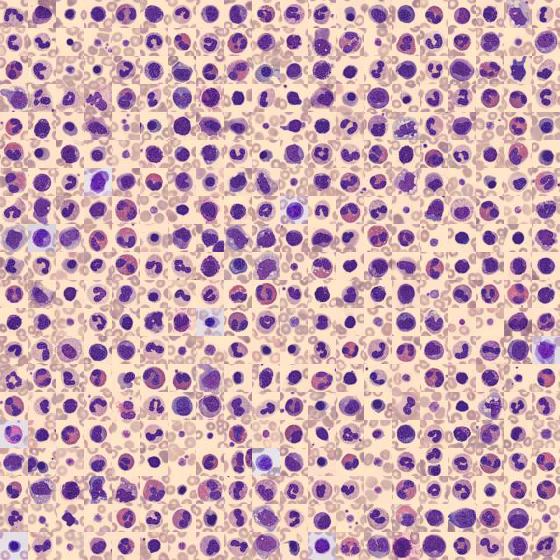

In [19]:
train_dataset.montage(length=20)

In [20]:
class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 100,
        output_channels: int = 3,
        output_size: int = 64
    ):
        super().__init__()
        assert output_size % 16 == 0, "Output size must be divisible by 16 (e.g., 64, 128)"

        self.latent_dim = latent_dim
        self.output_size = output_size
        self.output_channels = output_channels
        self.init_size = output_size // 16  # Initial feature map size (e.g., 4x4 if 64x64 output)

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.ReLU(True)
        )

        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2),  # 4 -> 8
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 8 -> 16
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 16 -> 32
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),  # 32 -> 64
            nn.Conv2d(32, output_channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # or Tanh if your data is scaled to [-1, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.fc(z)
        out = out.view(z.size(0), 256, self.init_size, self.init_size)
        img = self.upsample(out)
        return img

In [21]:
model = Generator(latent_dim=100, output_channels=3, output_size=64)

for images, labels in train_loader:
    print("Images shape (real):", images.shape)  # np. [128, 3, 64, 64] po preprocessing

    batch_size = images.size(0)
    latent_dim = 100
    z = torch.randn(batch_size, latent_dim)  # [128, 100]

    output = model(z)  # [128, 3, 64, 64]
    print("Generated image shape:", output.shape)
    break

Images shape (real): torch.Size([128, 3, 64, 64])
Generated image shape: torch.Size([128, 3, 64, 64])


In [22]:
class Discriminator(nn.Module):
    def __init__(
        self,
        input_channels: int = 3,
        input_size: int = 64
    ):
        super().__init__()
        assert input_size % 16 == 0, "Input size must be divisible by 16 (e.g., 64, 128)"

        self.input_channels = input_channels
        self.input_size = input_size
        self.final_size = input_size // 16  # Zakładamy 4 kroki downsamplingu: 64 → 32 → 16 → 8 → 4

        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=4, stride=2, padding=1),  # 64x64 → 32x32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32 → 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 16x16 → 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 8x8 → 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * self.final_size * self.final_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        out = self.classifier(x)
        return out

In [23]:
def train_gan(
    generator: nn.Module,
    discriminator: nn.Module,
    optimizer_G: optim.Optimizer,
    optimizer_D: optim.Optimizer,
    adversarial_loss: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 20,
    latent_dim: int = 100,
    run: 'neptune.Run' = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
) -> None:
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    for epoch in range(num_epochs):
        generator.train()
        discriminator.train()
        total_g_loss = 0.0
        total_d_loss = 0.0

        for real_images, _ in train_loader:  # etykiety niepotrzebne
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # === Etap 1: TRENUJEMY DYSKRYMINATORA ===
            optimizer_D.zero_grad()

            # Dane rzeczywiste
            real_labels = torch.full((batch_size, 1), 0.9, device=device)  # label smoothing
            real_preds = discriminator(real_images)
            real_loss = adversarial_loss(real_preds, real_labels)

            # Dane sztuczne
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()  # odłączone od gradientów Generatora
            fake_labels = torch.zeros((batch_size, 1), device=device)
            fake_preds = discriminator(fake_images)
            fake_loss = adversarial_loss(fake_preds, fake_labels)

            # Całkowita strata dyskryminatora
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # === Etap 2: TRENUJEMY GENERATOR ===
            optimizer_G.zero_grad()

            z = torch.randn(batch_size, latent_dim, device=device)
            generated_images = generator(z)
            preds = discriminator(generated_images)

            g_loss = adversarial_loss(preds, real_labels)  # generator chce oszukać dyskryminator
            g_loss.backward()
            optimizer_G.step()

            # === Logging ===
            total_g_loss += g_loss.item()
            total_d_loss += d_loss.item()

            if run:
                run["train/step/g_loss"].append(g_loss.item())
                run["train/step/d_loss"].append(d_loss.item())

        avg_g_loss = total_g_loss / len(train_loader)
        avg_d_loss = total_d_loss / len(train_loader)
        print(f"[Epoch {epoch+1}] G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")

        if run:
            run["train/epoch/g_loss"].append(avg_g_loss)
            run["train/epoch/d_loss"].append(avg_d_loss)

            # Przykładowe wygenerowane obrazki
            generator.eval()
            with torch.no_grad():
                z = torch.randn(16, latent_dim, device=device)
                samples = generator(z).cpu()  # [16, 3, 64, 64]
                grid = torchvision.utils.make_grid(samples, nrow=4, normalize=True)
                run[f"train/epoch/{epoch+1}_samples"].upload(neptune.types.File.as_image(grid))


NameError: name 'DataLoader' is not defined